In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

## 1. Cargar Scores del Validation Set

In [18]:
# Configurar la ruta del run a analizar
# Opción 1: Especificar ruta directa
RUN_NAME = 'resnet50_20260111_002544'  # Cambiar por el run deseado

# Opción 2: Usar el más reciente (comentar la línea anterior y descomentar estas)
# outputs_dir = Path('../outputs')
# RUN_NAME = sorted(outputs_dir.glob('resnet50_*'))[-1].name

outputs_dir = Path('../outputs/comparison_02')
latest_run = outputs_dir / RUN_NAME
scores_path = latest_run / 'prediction_scores_test.csv'

print(f"Cargando scores desde: {scores_path}")
df = pd.read_csv(scores_path)
print(f"Total de muestras: {len(df)}")
print(f"Benignas: {(df['true_label']==0).sum()}")
print(f"Malignas: {(df['true_label']==1).sum()}")
df.head()

Cargando scores desde: ../outputs/comparison_02/resnet50_20260111_002544/prediction_scores_test.csv
Total de muestras: 17125
Benignas: 15067
Malignas: 2058


,true_label,predicted_score
0,0,0.2230
1,0,0.6353
2,0,0.1566
3,0,0.5347
4,0,0.3090


## 2. Histograma de Distribución de Scores

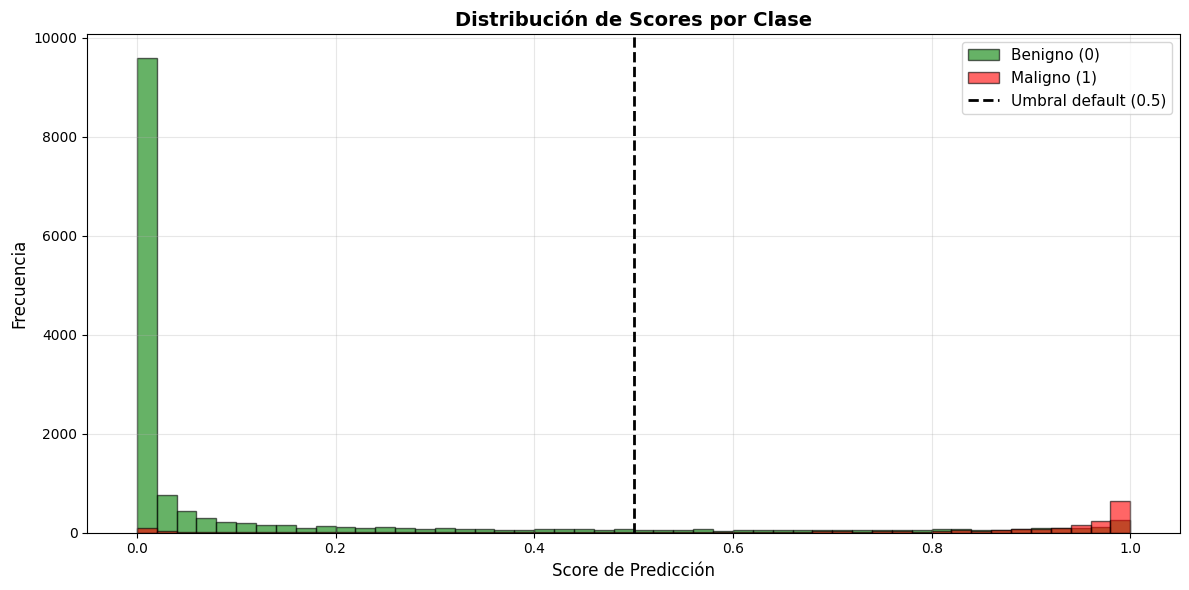


📊 Estadísticas de Scores:

Benignos:
  Media: 0.1374
  Mediana: 0.0037
  Std: 0.2683

Malignos:
  Media: 0.7873
  Mediana: 0.9414
  Std: 0.3019


In [19]:
# Separar scores por clase
scores_benign = df[df['true_label'] == 0]['predicted_score']
scores_malignant = df[df['true_label'] == 1]['predicted_score']

# Crear histograma
plt.figure(figsize=(12, 6))
plt.hist(scores_benign, bins=50, alpha=0.6, label='Benigno (0)', color='green', edgecolor='black')
plt.hist(scores_malignant, bins=50, alpha=0.6, label='Maligno (1)', color='red', edgecolor='black')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Umbral default (0.5)')
plt.xlabel('Score de Predicción', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Scores por Clase', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas de Scores:")
print(f"\nBenignos:")
print(f"  Media: {scores_benign.mean():.4f}")
print(f"  Mediana: {scores_benign.median():.4f}")
print(f"  Std: {scores_benign.std():.4f}")
print(f"\nMalignos:")
print(f"  Media: {scores_malignant.mean():.4f}")
print(f"  Mediana: {scores_malignant.median():.4f}")
print(f"  Std: {scores_malignant.std():.4f}")

## 3. Análisis de Umbrales

Probar diferentes umbrales para encontrar el punto óptimo de balance.

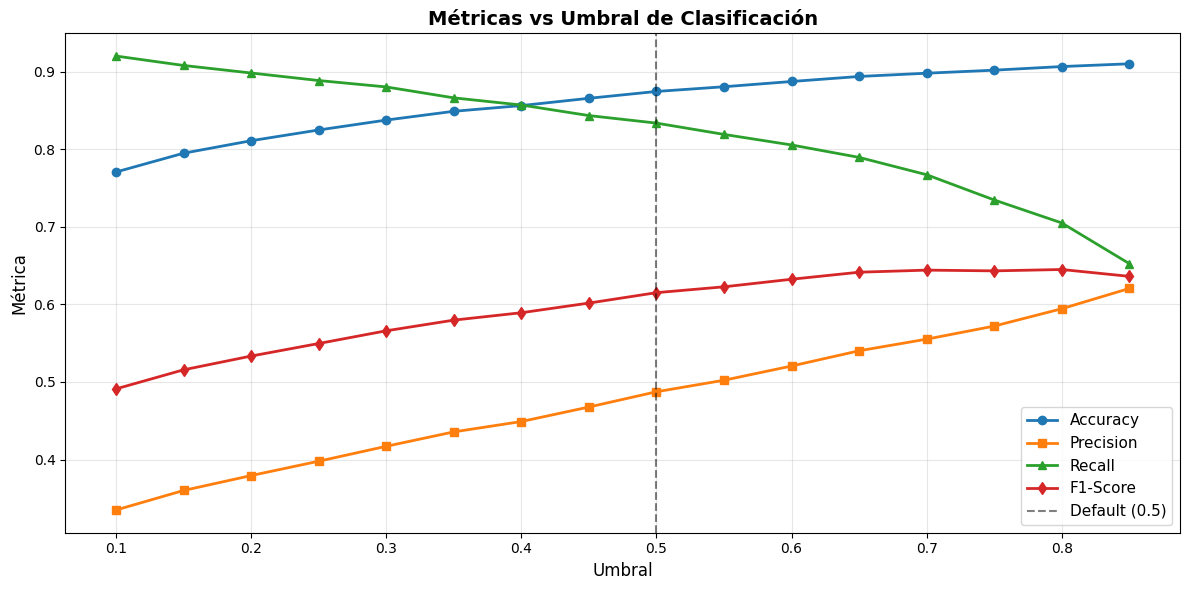


🎯 Umbrales Recomendados:

Mejor F1-Score: 0.80
  Accuracy: 0.9067
  Precision: 0.5944
  Recall: 0.7051
  F1: 0.6450

Mejor Accuracy: 0.85
  Accuracy: 0.9103
  Precision: 0.6206
  Recall: 0.6526
  F1: 0.6362


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Probar diferentes umbrales
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for threshold in thresholds:
    y_pred = (df['predicted_score'] >= threshold).astype(int)
    y_true = df['true_label']
    
    results.append({
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)

# Graficar métricas vs umbral
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(results_df['threshold'], results_df['accuracy'], 'o-', label='Accuracy', linewidth=2)
ax.plot(results_df['threshold'], results_df['precision'], 's-', label='Precision', linewidth=2)
ax.plot(results_df['threshold'], results_df['recall'], '^-', label='Recall', linewidth=2)
ax.plot(results_df['threshold'], results_df['f1'], 'd-', label='F1-Score', linewidth=2)
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Default (0.5)')
ax.set_xlabel('Umbral', fontsize=12)
ax.set_ylabel('Métrica', fontsize=12)
ax.set_title('Métricas vs Umbral de Clasificación', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Encontrar mejores umbrales
best_f1_idx = results_df['f1'].idxmax()
best_acc_idx = results_df['accuracy'].idxmax()

print(f"\n🎯 Umbrales Recomendados:")
print(f"\nMejor F1-Score: {results_df.loc[best_f1_idx, 'threshold']:.2f}")
print(f"  Accuracy: {results_df.loc[best_f1_idx, 'accuracy']:.4f}")
print(f"  Precision: {results_df.loc[best_f1_idx, 'precision']:.4f}")
print(f"  Recall: {results_df.loc[best_f1_idx, 'recall']:.4f}")
print(f"  F1: {results_df.loc[best_f1_idx, 'f1']:.4f}")

print(f"\nMejor Accuracy: {results_df.loc[best_acc_idx, 'threshold']:.2f}")
print(f"  Accuracy: {results_df.loc[best_acc_idx, 'accuracy']:.4f}")
print(f"  Precision: {results_df.loc[best_acc_idx, 'precision']:.4f}")
print(f"  Recall: {results_df.loc[best_acc_idx, 'recall']:.4f}")
print(f"  F1: {results_df.loc[best_acc_idx, 'f1']:.4f}")

## 4. Tabla Completa de Resultados

In [21]:
# Mostrar tabla completa
results_df.style.highlight_max(subset=['accuracy', 'precision', 'recall', 'f1'], color='lightgreen')

,threshold,accuracy,precision,recall,f1
0,0.100000,0.770745,0.334866,0.920311,0.491055
1,0.150000,0.794978,0.360046,0.908163,0.515657
2,0.200000,0.811095,0.379282,0.898445,0.533391
3,0.250000,0.824934,0.397782,0.888727,0.549579
4,0.300000,0.837723,0.417031,0.880466,0.565985
5,0.350000,0.849051,0.435622,0.866375,0.579743
6,0.400000,0.856409,0.448969,0.857143,0.589277
7,0.450000,0.865810,0.467672,0.843537,0.601733
8,0.500000,0.874628,0.487362,0.833819,0.615164
9,0.550000,0.880701,0.502234,0.819242,0.622715


## 5. Visualización de Separación de Clases

/tmp/ipykernel_8826/509726732.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(data_to_plot, labels=['Benigno', 'Maligno'], patch_artist=True,


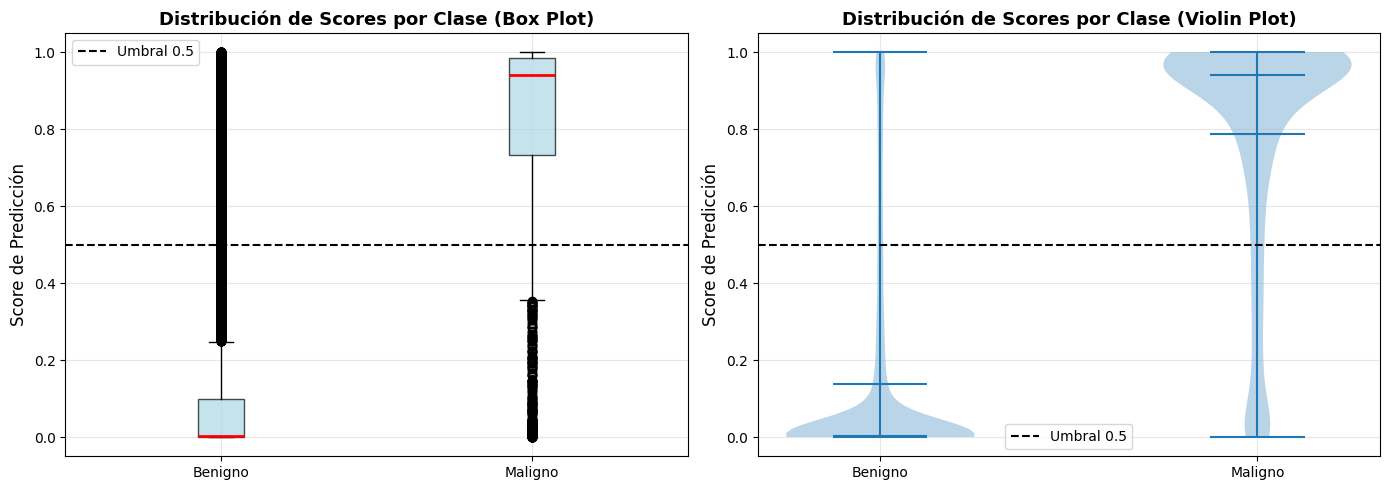

In [22]:
# Box plot para ver la separación
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
data_to_plot = [scores_benign, scores_malignant]
ax1.boxplot(data_to_plot, labels=['Benigno', 'Maligno'], patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax1.axhline(y=0.5, color='black', linestyle='--', label='Umbral 0.5')
ax1.set_ylabel('Score de Predicción', fontsize=12)
ax1.set_title('Distribución de Scores por Clase (Box Plot)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Violin plot
positions = [1, 2]
parts = ax2.violinplot(data_to_plot, positions=positions, showmeans=True, showmedians=True)
ax2.axhline(y=0.5, color='black', linestyle='--', label='Umbral 0.5')
ax2.set_xticks(positions)
ax2.set_xticklabels(['Benigno', 'Maligno'])
ax2.set_ylabel('Score de Predicción', fontsize=12)
ax2.set_title('Distribución de Scores por Clase (Violin Plot)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Métricas Avanzadas (AUROC y AUPRC)

**Estas métricas son CRÍTICAS para comparación con estado del arte:**
- **AUROC**: Mide discriminación independiente del threshold
- **AUPRC**: Métrica clave para datasets desbalanceados

In [23]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_true = df['true_label']
y_scores = df['predicted_score']

# Calcular ROC curve y AUROC
fpr, tpr, thresholds_roc = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Calcular Precision-Recall curve y AUPRC
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_true, y_scores)
auprc = average_precision_score(y_true, y_scores)

print("📊 MÉTRICAS CLAVE PARA COMPARACIÓN CON ESTADO DEL ARTE:")
print(f"\n🎯 AUROC (ROC AUC): {roc_auc:.4f}")
print(f"   - Estado del arte melanoma: ~0.90-0.95")
print(f"   - Baseline (random): 0.50")

print(f"\n🎯 AUPRC (PR AUC): {auprc:.4f}")
print(f"   - Estado del arte melanoma: ~0.75-0.85")
print(f"   - Baseline (prevalencia): {y_true.mean():.4f}")

print(f"\n⚠️  ANÁLISIS:")
if roc_auc >= 0.90:
    print("   ✅ AUROC excelente - comparable con estado del arte")
elif roc_auc >= 0.85:
    print("   ⚠️  AUROC bueno pero por debajo del estado del arte")
else:
    print("   ❌ AUROC insuficiente para publicación")

if auprc >= 0.75:
    print("   ✅ AUPRC excelente - maneja bien el desbalance")
elif auprc >= 0.65:
    print("   ⚠️  AUPRC aceptable pero mejorable")
else:
    print("   ❌ AUPRC bajo - modelo tiene dificultad con clase minoritaria")

📊 MÉTRICAS CLAVE PARA COMPARACIÓN CON ESTADO DEL ARTE:

🎯 AUROC (ROC AUC): 0.9228
   - Estado del arte melanoma: ~0.90-0.95
   - Baseline (random): 0.50

🎯 AUPRC (PR AUC): 0.6171
   - Estado del arte melanoma: ~0.75-0.85
   - Baseline (prevalencia): 0.1202

⚠️  ANÁLISIS:
   ✅ AUROC excelente - comparable con estado del arte
   ❌ AUPRC bajo - modelo tiene dificultad con clase minoritaria


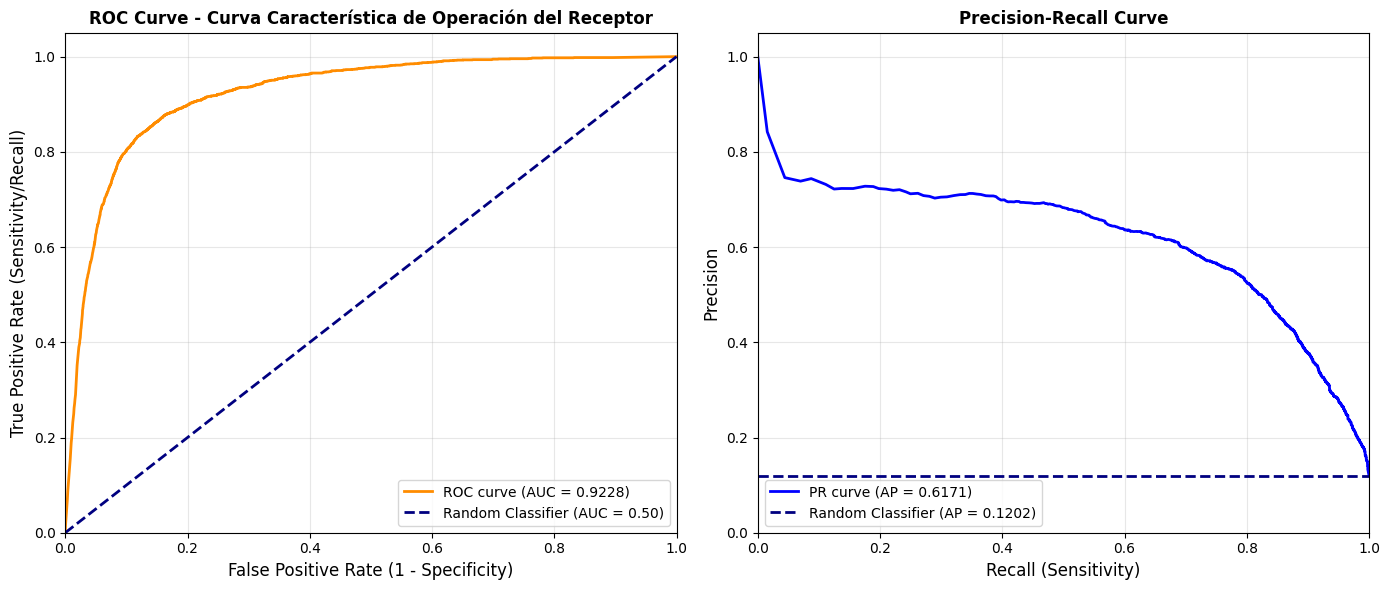


✅ Curvas guardadas en: figures/roc_pr_curves.png


In [24]:
# Visualizar ROC Curve y Precision-Recall Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax1.set_ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
ax1.set_title('ROC Curve - Curva Característica de Operación del Receptor', fontsize=12, fontweight='bold')
ax1.legend(loc="lower right", fontsize=10)
ax1.grid(alpha=0.3)

# Precision-Recall Curve
baseline_prevalence = y_true.mean()
ax2.plot(recall_curve, precision_curve, color='blue', lw=2, label=f'PR curve (AP = {auprc:.4f})')
ax2.axhline(y=baseline_prevalence, color='navy', lw=2, linestyle='--', 
            label=f'Random Classifier (AP = {baseline_prevalence:.4f})')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax2.legend(loc="lower left", fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Comparación con Estado del Arte

**Tabla de referencia para melanoma detection:**

| Métrica | Tu Modelo | Estado del Arte | Status |
|---------|-----------|-----------------|---------|
| AUROC | ? | 0.90 - 0.95 | ? |
| AUPRC | ? | 0.75 - 0.85 | ? |
| Sensitivity (Recall) | 80.4% | 85% - 95% | ⚠️ |
| Specificity | ? | 85% - 90% | ? |
| Accuracy | 89.4% | 88% - 92% | ✅ |

**⚠️ IMPORTANTE:** Accuracy sola NO es suficiente en datasets desbalanceados.
Las métricas AUROC y AUPRC son las que realmente importan para comparación.

## 8. Comparación de Tres Modelos - Tablas de Resultados

Comparar las métricas de tres modelos diferentes mostrando sus tablas de umbrales lado a lado.

In [49]:
# Configurar los tres modelos a comparar
RUN_NAMES = [
    'comparision_resnet/resnet50_20260110_001917-normal',
    'comparision_resnet/resnet50_20260111_215331-mas-unfreeze',
    'comparision_resnet/resnet50_20260111_220602-256dense'
]

outputs_dir = Path('../outputs/')

# Función para calcular métricas por umbral
def calculate_threshold_metrics(df, thresholds):
    results = []
    for threshold in thresholds:
        y_pred = (df['predicted_score'] >= threshold).astype(int)
        y_true = df['true_label']
        
        results.append({
            'threshold': threshold,
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0)
        })
    return pd.DataFrame(results)

# Procesar cada modelo
thresholds = np.arange(0.1, 0.9, 0.05)
model_results = {}

for run_name in RUN_NAMES:
    run_path = outputs_dir / run_name
    scores_path = run_path / 'prediction_scores_test.csv'
    
    if scores_path.exists():
        df_scores = pd.read_csv(scores_path)
        results_df_temp = calculate_threshold_metrics(df_scores, thresholds)
        model_results[run_name] = results_df_temp
        print(f"✅ Cargado: {run_name}")
    else:
        print(f"❌ No encontrado: {scores_path}")

print(f"\n📊 Total de modelos cargados: {len(model_results)}")


✅ Cargado: comparision_resnet/resnet50_20260110_001917-normal
✅ Cargado: comparision_resnet/resnet50_20260111_215331-mas-unfreeze
✅ Cargado: comparision_resnet/resnet50_20260111_220602-256dense

📊 Total de modelos cargados: 3


In [50]:
# Mostrar las tres tablas de resultados
import matplotlib.pyplot as plt
from IPython.display import display, HTML

print("="*80)
print("COMPARACIÓN DE MODELOS - MÉTRICAS POR UMBRAL")
print("="*80)

for i, (run_name, results_df_model) in enumerate(model_results.items(), 1):
    print(f"\n{'='*80}")
    print(f"MODELO {i}: {run_name}")
    print(f"{'='*80}\n")
    
    # Encontrar mejores umbrales
    best_f1_idx = results_df_model['f1'].idxmax()
    best_acc_idx = results_df_model['accuracy'].idxmax()
    
    print(f"🎯 Mejor F1-Score: {results_df_model.loc[best_f1_idx, 'threshold']:.2f} → F1={results_df_model.loc[best_f1_idx, 'f1']:.4f}")
    print(f"🎯 Mejor Accuracy: {results_df_model.loc[best_acc_idx, 'threshold']:.2f} → Acc={results_df_model.loc[best_acc_idx, 'accuracy']:.4f}")
    
    # Mostrar tabla con formato
    styled_table = results_df_model.style.highlight_max(
        subset=['accuracy', 'precision', 'recall', 'f1'], 
        color='lightgreen'
    ).format({
        'threshold': '{:.2f}',
        'accuracy': '{:.4f}',
        'precision': '{:.4f}',
        'recall': '{:.4f}',
        'f1': '{:.4f}'
    })
    
    display(styled_table)
    print("\n")


COMPARACIÓN DE MODELOS - MÉTRICAS POR UMBRAL

MODELO 1: comparision_resnet/resnet50_20260110_001917-normal

🎯 Mejor F1-Score: 0.75 → F1=0.6653
🎯 Mejor Accuracy: 0.85 → Acc=0.9186


,threshold,accuracy,precision,recall,f1
0,0.10,0.7984,0.3661,0.9257,0.5246
1,0.15,0.8241,0.3986,0.9125,0.5549
2,0.20,0.8385,0.4196,0.8980,0.5720
3,0.25,0.8509,0.4403,0.8863,0.5883
4,0.30,0.8606,0.4580,0.8732,0.6008
5,0.35,0.8686,0.4742,0.8591,0.6111
6,0.40,0.8751,0.4886,0.8465,0.6196
7,0.45,0.8823,0.5063,0.8338,0.6301
8,0.50,0.8896,0.5264,0.8149,0.6396
9,0.55,0.8964,0.5473,0.7983,0.6494





MODELO 2: comparision_resnet/resnet50_20260111_215331-mas-unfreeze

🎯 Mejor F1-Score: 0.80 → F1=0.6476
🎯 Mejor Accuracy: 0.85 → Acc=0.9104


,threshold,accuracy,precision,recall,f1
0,0.10,0.7787,0.3441,0.9281,0.5020
1,0.15,0.8019,0.3686,0.9096,0.5246
2,0.20,0.8178,0.3882,0.8955,0.5416
3,0.25,0.8323,0.4087,0.8853,0.5592
4,0.30,0.8444,0.4281,0.8766,0.5753
5,0.35,0.8547,0.4460,0.8649,0.5885
6,0.40,0.8626,0.4612,0.8523,0.5985
7,0.45,0.8706,0.4783,0.8445,0.6107
8,0.50,0.8773,0.4938,0.8294,0.6190
9,0.55,0.8832,0.5088,0.8139,0.6262





MODELO 3: comparision_resnet/resnet50_20260111_220602-256dense

🎯 Mejor F1-Score: 0.65 → F1=0.6592
🎯 Mejor Accuracy: 0.80 → Acc=0.9141


,threshold,accuracy,precision,recall,f1
0,0.10,0.7772,0.3389,0.8984,0.4921
1,0.15,0.8005,0.3645,0.8878,0.5168
2,0.20,0.8209,0.3905,0.8741,0.5398
3,0.25,0.8381,0.4163,0.8630,0.5617
4,0.30,0.8506,0.4373,0.8494,0.5774
5,0.35,0.8638,0.4629,0.8348,0.5956
6,0.40,0.8768,0.4924,0.8222,0.6159
7,0.45,0.8862,0.5172,0.8052,0.6298
8,0.50,0.8922,0.5349,0.7896,0.6378
9,0.55,0.8988,0.5572,0.7692,0.6463


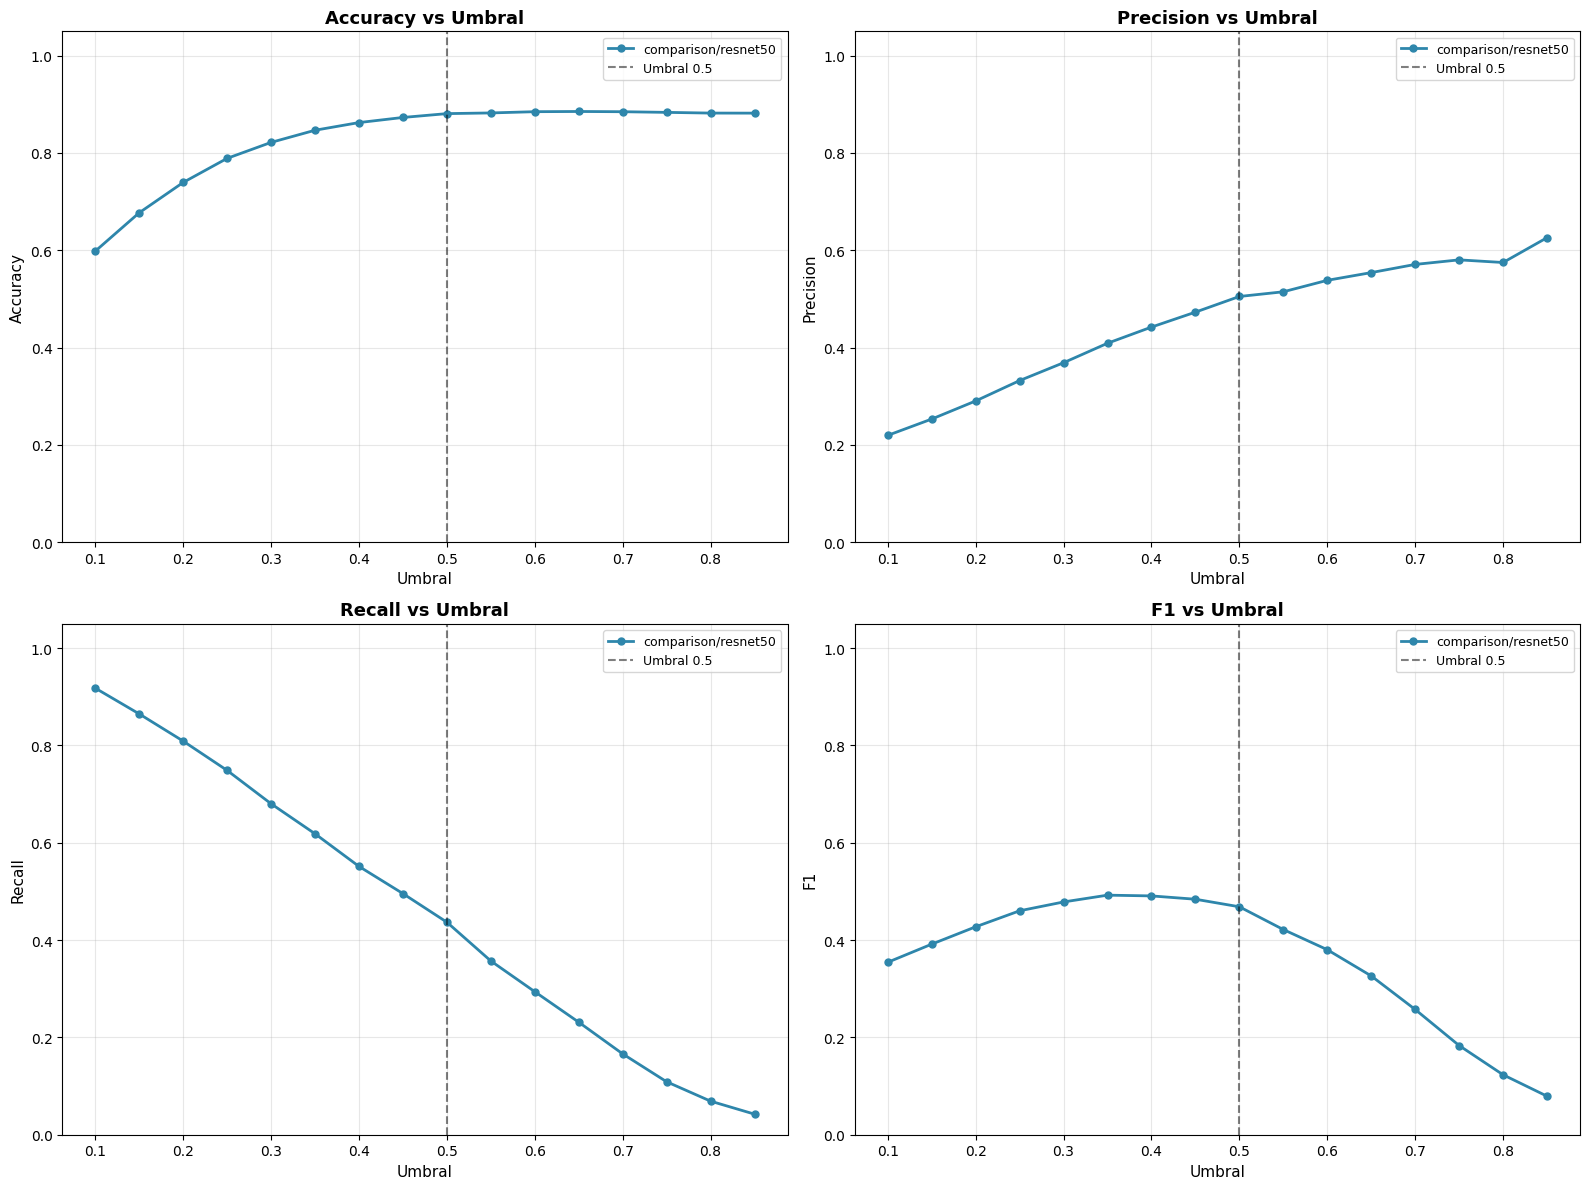

In [44]:
# Visualización comparativa de los tres modelos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['accuracy', 'precision', 'recall', 'f1']
colors = ['#2E86AB', '#A23B72', '#F18F01']
model_names = [name.split('_')[0] for name in RUN_NAMES]

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    for i, (run_name, results_df_model) in enumerate(model_results.items()):
        ax.plot(results_df_model['threshold'], results_df_model[metric], 
                'o-', label=model_names[i], linewidth=2, color=colors[i], markersize=5)
    
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='Umbral 0.5')
    ax.set_xlabel('Umbral', fontsize=11)
    ax.set_ylabel(metric.capitalize(), fontsize=11)
    ax.set_title(f'{metric.capitalize()} vs Umbral', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()